In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [51]:
df = pd.DataFrame({
    "Task": [
        "Data Cleaning",
        "Exploratory data analysis",
        "Data preprocessing",
        "Classification model",
        "Model comparison",
        "API",
        "Docker",
        "Report preparation"
    ],
    "Collaborator": [
        "Celica Krigul",
        "Ema Stangova",
        "Delia Clara Podaru Savu",
        "Sarah Bordi",
        "Szymon Majorek",
        "Sara Ortiz Couvet",
        "Angela Coloma Escudero",
        "All team members"
    ],
    "Start": [
        "06/01/2026",
        "07/01/2026",
        "09/01/2026",
        "10/01/2026",
        "12/01/2026",
        "14/01/2026",
        "17/01/2026",
        "20/01/2026",
    ],
    "End": [
        "07/01/2026",
        "09/01/2026",
        "11/01/2026",
        "11/01/2026",
        "14/01/2026",
        "17/01/2026",
        "23/01/2026",
        "23/01/2026"
    ],
})

In [52]:
df["Start"] = pd.to_datetime(df["Start"], format="%d/%m/%Y")
df["End"] = pd.to_datetime(df["End"], format="%d/%m/%Y")
df["Duration"] = (df["End"] - df["Start"]).dt.days

In [53]:
collaborators = df["Collaborator"].unique()
palette = sns.color_palette("YlGnBu", n_colors=len(collaborators))
color_map = dict(zip(collaborators, palette))

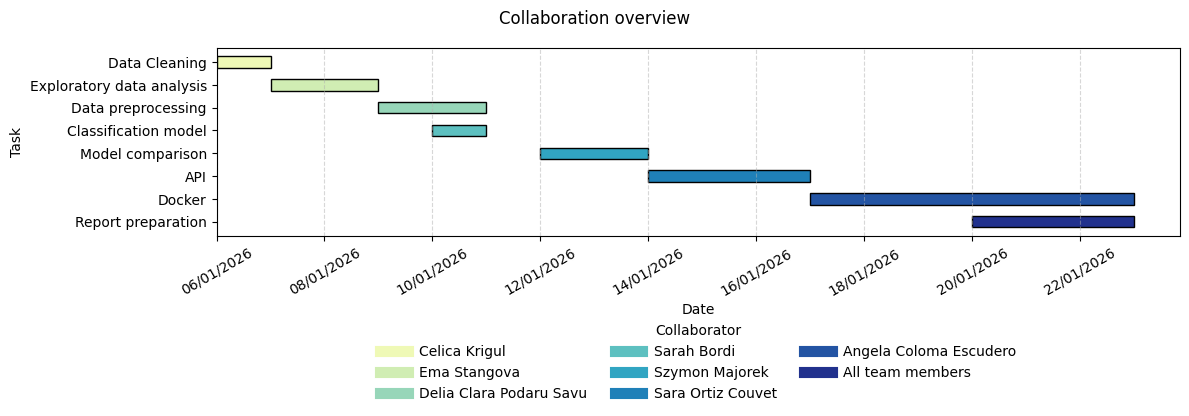

In [54]:
fig, ax = plt.subplots(figsize=(12, 5))

for i, row in df.iterrows():
    ax.barh(
        y=row["Task"],                    
        width=row["Duration"],
        left=row["Start"],
        color=color_map[row["Collaborator"]],
        edgecolor="black",
        height=0.5
    )

ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m/%Y"))
plt.xticks(rotation=30)

ax.grid(axis="x", linestyle="--", alpha=0.5)

ax.set_xlabel("Date")
ax.set_ylabel("Task")

legend_handles = [
    plt.Line2D([0], [0], color=color_map[c], lw=8, label=c)
    for c in collaborators
]

ax.legend(
    handles=legend_handles,
    title="Collaborator",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.40),
    ncol=3,
    frameon=False
)
ax.invert_yaxis()

plt.suptitle("Collaboration overview")

plt.tight_layout()
plt.savefig("collaboration_chart.png", dpi=600)
plt.show()